# A/B Test Analysis & Hypotheses Prioritization (Versión ampliada)
En este cuaderno desglosaremos cada paso del proyecto de **marketing data‑driven** para demostrar:
1. **Cómo generar datasets sintéticos realistas** que permitan reproducir el flujo completo sin exponer datos confidenciales.
2. **Cómo priorizar hipótesis** de crecimiento con los frameworks **ICE** y **RICE**, interpretando sus resultados.
3. **Cómo analizar un experimento A/B** desde el preprocesamiento de datos hasta la toma de decisiones, aplicando estadísticas y visualizaciones.

Cada sección comienza con una mini‑guía que explica **qué vamos a hacer, por qué es importante y cómo lo haremos**. El código está comentado para que puedas adaptarlo a tus propios datos.

# A/B Test Analysis & Hypotheses Prioritization
Este cuaderno crea datos sintéticos basados en el diccionario de datos proporcionado, los preprocesa y resuelve paso a paso los requerimientos de priorización de hipótesis y el análisis de un test A/B.

Cada sección incluye explicaciones teóricas y código reproducible.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
from datetime import timedelta
sns.set_style('whitegrid')
np.random.seed(42)

## 1. Generador de datos sintéticos

**Objetivo de esta sección:**
- Crear un *data generator* que produzca archivos CSV con la misma estructura que los datasets reales.
- Asegurar reproducibilidad (semilla aleatoria fija) y métricas de negocio coherentes.

**Cómo lo haremos:**
1. Definimos una clase `SyntheticDataGenerator` que encapsula la lógica.
2. Generamos `hypotheses_us.csv`, `visits_us.csv` y `orders_us.csv`.
3. Guardamos los archivos en disco para usarlos en el resto del flujo.

In [2]:
class SyntheticDataGenerator:
    """Genera datasets sintéticos para hipótesis, pedidos y visitas."""
    def __init__(self, start_date='2021-01-01', days=30):
        self.start_date = pd.to_datetime(start_date)
        self.days = days

    def create_hypotheses(self, path='hypotheses_us.csv'):
        descriptions = [
            'Agregar descripciones de productos cortas a cada pantalla de producto',
            'Mostrar definitivamente los detalles del producto',
            'Añadir recomendaciones de productos similares',
            'Implementar búsqueda por voz',
            'Reducir el tiempo de carga de la página',
            'Añadir un programa de fidelidad',
            'Ofrecer descuentos personalizados',
            'Añadir reseñas de clientes verificadas',
            'Mejorar la navegación en dispositivos móviles'
        ]
        n = len(descriptions)
        df = pd.DataFrame({
            'Hypothesis': descriptions,
            'Reach': np.random.randint(1, 11, n),
            'Impact': np.random.randint(1, 11, n),
            'Confidence': np.random.randint(1, 11, n),
            'Effort': np.random.randint(1, 11, n)
        })
        df.to_csv(path, index=False)
        return df

    def create_visits(self, path='visits_us.csv'):
        dates = pd.date_range(self.start_date, periods=self.days)
        groups = ['A', 'B']
        data = []
        for date in dates:
            for g in groups:
                baseline = 1000 if g == 'A' else 1050  # B tiene ~5% más visitas
                visits = baseline + np.random.randint(-50, 50)
                data.append({'date': date, 'group': g, 'visits': visits})
        df = pd.DataFrame(data)
        df.to_csv(path, index=False)
        return df

    def create_orders(self, visits_df, path='orders_us.csv'):
        orders = []
        tx_id = 1
        for _, row in visits_df.iterrows():
            # Conversión base: 3% para A, 3.5% para B
            conv_rate = 0.03 if row['group'] == 'A' else 0.035
            n_orders = np.random.binomial(row['visits'], conv_rate)
            user_pool = np.random.choice(range(1000000, 2000000), size=row['visits'], replace=False)
            buyers = np.random.choice(user_pool, size=n_orders, replace=False)
            for user in buyers:
                revenue = np.random.gamma(shape=2.0, scale=25) * 10  # media~500
                orders.append({
                    'transactionId': tx_id,
                    'visitorId': user,
                    'date': row['date'],
                    'revenue': round(revenue, 2),
                    'group': row['group']
                })
                tx_id += 1
        df = pd.DataFrame(orders)
        df.to_csv(path, index=False)
        return df


In [4]:
# Generamos los archivos CSV sintéticos
gen = SyntheticDataGenerator(start_date='2021-01-01', days=31)
hypotheses_df = gen.create_hypotheses()
visits_df = gen.create_visits()
orders_df = gen.create_orders(visits_df)



In [5]:
hypotheses_df.head()

,Hypothesis,Reach,Impact,Confidence,Effort
0,Agregar descripciones de productos cortas a ca...,1,6,5,9
1,Mostrar definitivamente los detalles del producto,6,7,4,7
2,Añadir recomendaciones de productos similares,10,10,4,8
3,Implementar búsqueda por voz,6,7,8,10
4,Reducir el tiempo de carga de la página,9,5,10,5


In [6]:
visits_df.head()

,date,group,visits
0,2021-01-01,A,1023
1,2021-01-01,B,1047
2,2021-01-02,A,988
3,2021-01-02,B,1068
4,2021-01-03,A,1037


In [7]:
orders_df.head()

,transactionId,visitorId,date,revenue,group
0,1,1673035,2021-01-01,229.57,A
1,2,1365447,2021-01-01,236.55,A
2,3,1542849,2021-01-01,257.98,A
3,4,1457215,2021-01-01,344.80,A
4,5,1057094,2021-01-01,806.54,A


## 2. Parte 1 – Priorizar hipótesis (ICE y RICE)

**Objetivo de esta sección:** Evaluar rápidamente qué hipótesis deberían implementarse primero para maximizar el impacto.

**Metodología:**
1. **ICE**: prioriza ideas por impacto y confianza, penalizando el esfuerzo.
2. **RICE**: añade la dimensión de *alcance* (Reach), útil cuando diferentes ideas afectan a distintos tamaños de audiencia.

Compararemos ambos rankings y extraeremos conclusiones sobre cómo cambia la priorización.

La priorización ayuda a elegir qué ideas implementar primero.

- **ICE**: `(Impact × Confidence) / Effort`
- **RICE**: `(Reach × Impact × Confidence) / Effort`

A continuación calculamos ambas métricas y comparamos la diferencia.

In [8]:
hypotheses_df.head()

,Hypothesis,Reach,Impact,Confidence,Effort
0,Agregar descripciones de productos cortas a ca...,1,6,5,9
1,Mostrar definitivamente los detalles del producto,6,7,4,7
2,Añadir recomendaciones de productos similares,10,10,4,8
3,Implementar búsqueda por voz,6,7,8,10
4,Reducir el tiempo de carga de la página,9,5,10,5


In [9]:
# Cálculo de ICE y RICE
hypotheses_df['ICE'] = (hypotheses_df['Impact'] * hypotheses_df['Confidence']) / hypotheses_df['Effort']

hypotheses_df['RICE'] = (
    hypotheses_df['Reach'] * hypotheses_df['Impact'] * hypotheses_df['Confidence']
) / hypotheses_df['Effort']

In [10]:
hypotheses_df.head()

,Hypothesis,Reach,Impact,Confidence,Effort,ICE,RICE
0,Agregar descripciones de productos cortas a ca...,1,6,5,9,3.333333,3.333333
1,Mostrar definitivamente los detalles del producto,6,7,4,7,4.000000,24.000000
2,Añadir recomendaciones de productos similares,10,10,4,8,5.000000,50.000000
3,Implementar búsqueda por voz,6,7,8,10,5.600000,33.600000
4,Reducir el tiempo de carga de la página,9,5,10,5,10.000000,90.000000


In [11]:
# Rankings
ice_rank = hypotheses_df.sort_values(by='ICE', ascending=False)
rice_rank = hypotheses_df.sort_values(by='RICE', ascending=False)

display(ice_rank[['Hypothesis', 'ICE']].reset_index(drop=True))
display(rice_rank[['Hypothesis', 'RICE']].reset_index(drop=True))

,Hypothesis,ICE
0,Reducir el tiempo de carga de la página,10.000000
1,Implementar búsqueda por voz,5.600000
2,Añadir recomendaciones de productos similares,5.000000
3,Añadir un programa de fidelidad,4.666667
4,Añadir reseñas de clientes verificadas,4.500000
5,Mostrar definitivamente los detalles del producto,4.000000
6,Agregar descripciones de productos cortas a ca...,3.333333
7,Mejorar la navegación en dispositivos móviles,1.800000
8,Ofrecer descuentos personalizados,0.111111


,Hypothesis,RICE
0,Reducir el tiempo de carga de la página,90.000000
1,Añadir recomendaciones de productos similares,50.000000
2,Implementar búsqueda por voz,33.600000
3,Añadir un programa de fidelidad,32.666667
4,Mostrar definitivamente los detalles del producto,24.000000
5,Añadir reseñas de clientes verificadas,18.000000
6,Mejorar la navegación en dispositivos móviles,14.400000
7,Agregar descripciones de productos cortas a ca...,3.333333
8,Ofrecer descuentos personalizados,1.000000


### Discusión
Comparando ambos rankings podemos identificar cómo el factor **Reach** influye en RICE. Las hipótesis con alto alcance tienden a subir posiciones en RICE, mientras que ICE favorece ideas con combinación de alto _impact_ y _confianza_ frente a menor _esfuerzo_.

## 3. Parte 2 – Análisis del test A/B

**Objetivo de esta sección:** Realizar un *end‑to‑end* del análisis de un experimento A/B.

**Pasos clave:**
1. Verificar y limpiar datos (visitantes duplicados en ambos grupos, valores atípicos).
2. Visualizar métricas acumuladas para entender la dinámica temporal.
3. Calcular métricas operativas (conversión, AOV) y detectar anomalías.
4. Aplicar pruebas estadísticas adecuadas (proporciones para conversión; Mann‑Whitney para montos).
5. Tomar una decisión basada en evidencia.

Cada subsección explica *qué* mide la métrica, *por qué* es relevante y *cómo* interpretarla.

### 3.1 Ingreso acumulado por grupo

**Qué haremos:** Graficar el ingreso acumulado de cada grupo día a día.

**Por qué:** El crecimiento divergente puede indicar un efecto positivo de la variante.

**Cómo:** Agrupamos por fecha y aplicamos `cumsum()` para obtener la curva acumulativa.

In [12]:
orders_df.head()

,transactionId,visitorId,date,revenue,group
0,1,1673035,2021-01-01,229.57,A
1,2,1365447,2021-01-01,236.55,A
2,3,1542849,2021-01-01,257.98,A
3,4,1457215,2021-01-01,344.80,A
4,5,1057094,2021-01-01,806.54,A


In [14]:
# Preprocesamiento
orders_df['date'] = pd.to_datetime(orders_df['date'])
orders_df.head()

,transactionId,visitorId,date,revenue,group
0,1,1673035,2021-01-01,229.57,A
1,2,1365447,2021-01-01,236.55,A
2,3,1542849,2021-01-01,257.98,A
3,4,1457215,2021-01-01,344.80,A
4,5,1057094,2021-01-01,806.54,A


In [19]:
# Ingreso acumulado
cumulative_revenue = (
    orders_df.groupby(['group', 'date'])['revenue']
    .sum()
    .groupby(level=0)
    .cumsum()
    .reset_index()
)
cumulative_revenue.head()

,group,date,revenue
0,A,2021-01-01,17899.39
1,A,2021-01-02,31420.55
2,A,2021-01-03,46025.95
3,A,2021-01-04,58360.17
4,A,2021-01-05,73017.71


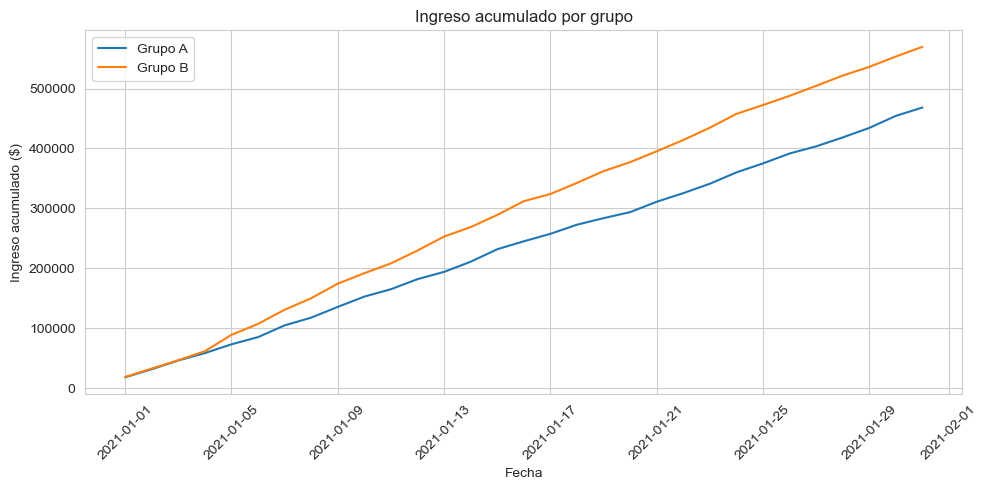

In [20]:
plt.figure(figsize=(10,5))
for grp in ['A', 'B']:
    grp_data = cumulative_revenue[cumulative_revenue['group']==grp]
    plt.plot(grp_data['date'], grp_data['revenue'], label=f'Grupo {grp}')
plt.title('Ingreso acumulado por grupo')
plt.xlabel('Fecha')
plt.ylabel('Ingreso acumulado ($)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Podemos observar la evolución del ingreso a lo largo de la prueba y detectar si uno de los grupos genera ingresos consistentemente mayores.

### 3.2 Tamaño de pedido promedio acumulado por grupo

**Qué haremos:** Analizar el *Average Order Value* (AOV) acumulado.

**Por qué:** Ayuda a entender si los grupos difieren en el tamaño de los pedidos, factor clave de revenue.

**Cómo:** Calculamos la media diaria y aplicamos `cummean()`.

In [21]:
# ticket medio diario
daily = orders_df.groupby(['group', 'date'])['revenue'].mean()
daily.head()

group  date      
A      2021-01-01    511.411143
       2021-01-02    482.898571
       2021-01-03    521.621429
       2021-01-04    493.368800
       2021-01-05    637.284348
Name: revenue, dtype: float64

In [22]:
# media acumulada por grupo, sin duplicar el nivel 'group'
avg_order = (
    daily
      .groupby(level=0, group_keys=False)        # evita la 2ª capa 'group'
      .apply(lambda s: s.expanding().mean())     # media acumulada
      .reset_index(name='revenue')               # pasa índice a columnas
)

avg_order.head()

,group,date,revenue
0,A,2021-01-01,511.411143
1,A,2021-01-02,497.154857
2,A,2021-01-03,505.310381
3,A,2021-01-04,502.324986
4,A,2021-01-05,529.316858


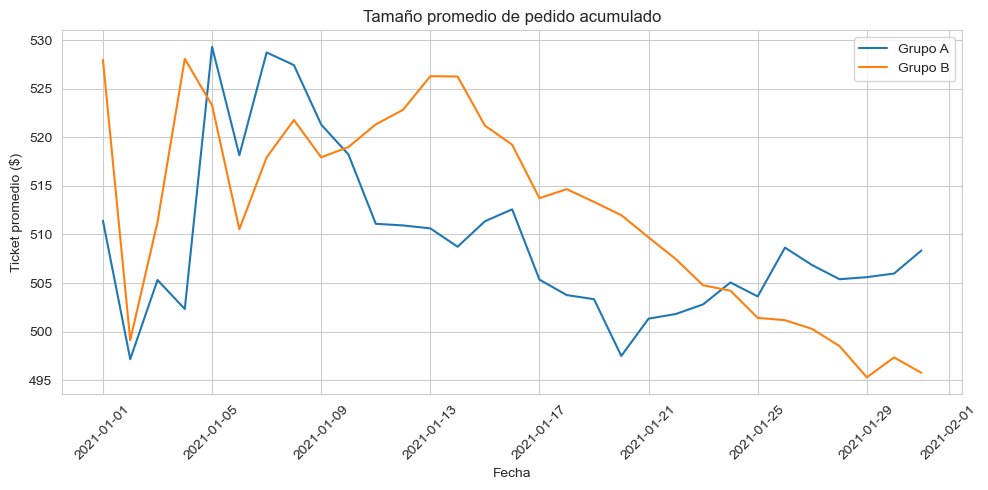

In [23]:
# gráfico
plt.figure(figsize=(10,5))
for g in ['A', 'B']:
    mask = avg_order['group'] == g
    plt.plot(avg_order.loc[mask, 'date'], avg_order.loc[mask, 'revenue'], label=f'Grupo {g}')
plt.title('Tamaño promedio de pedido acumulado')
plt.xlabel('Fecha'); plt.ylabel('Ticket promedio ($)')
plt.legend(); plt.xticks(rotation=45); plt.tight_layout(); plt.show()


Analizamos si el ticket promedio difiere significativamente entre grupos.

### 3.3 Diferencia relativa del ticket promedio (B vs A)

**Qué haremos:** Medir la diferencia relativa de AOV entre B y A.

**Por qué:** Una métrica normalizada facilita ver ventaja percentual.

**Cómo:** Calculamos `(B - A)/A` día a día.

In [24]:
merged_avg = (
    avg_order.pivot(index='date', columns='group', values='revenue')
    .reset_index()
)

merged_avg.head()

group,date,A,B
0,2021-01-01,511.411143,527.980571
1,2021-01-02,497.154857,499.118952
2,2021-01-03,505.310381,511.279302
3,2021-01-04,502.324986,528.078130
4,2021-01-05,529.316858,523.302689


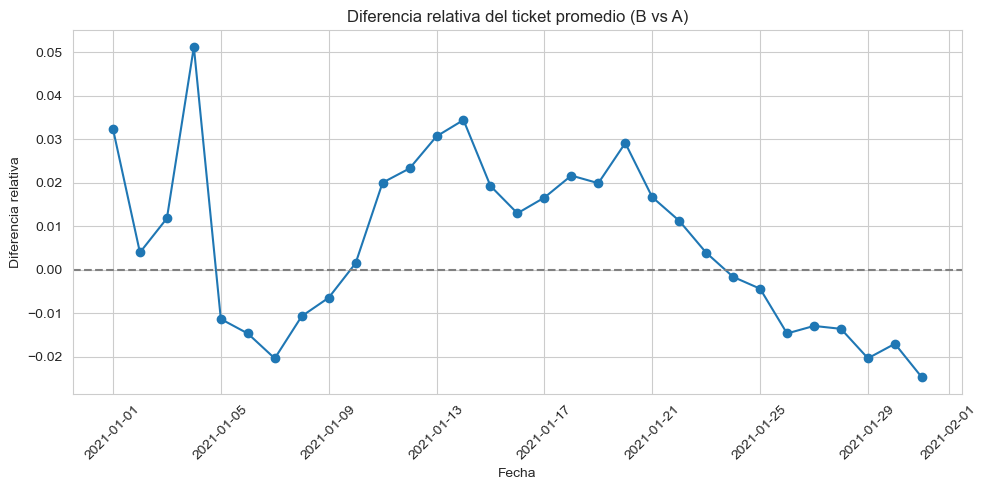

In [25]:
merged_avg['rel_diff'] = (merged_avg['B'] - merged_avg['A']) / merged_avg['A']

plt.figure(figsize=(10,5))
plt.plot(merged_avg['date'], merged_avg['rel_diff'], marker='o')
plt.axhline(0, color='gray', linestyle='--')
plt.title('Diferencia relativa del ticket promedio (B vs A)')
plt.xlabel('Fecha')
plt.ylabel('Diferencia relativa')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Una diferencia estable y positiva indicaría que B tiene un ticket promedio mayor.

### 3.4 Tasa de conversión diaria

**Qué haremos:** Calcular la tasa de conversión diaria.

**Por qué:** Conversion Rate (CR) es el KPI principal de muchos e‑commerce.

**Cómo:** `CR = pedidos / visitas` por grupo y fecha.

In [27]:
orders_df.head()

,transactionId,visitorId,date,revenue,group
0,1,1673035,2021-01-01,229.57,A
1,2,1365447,2021-01-01,236.55,A
2,3,1542849,2021-01-01,257.98,A
3,4,1457215,2021-01-01,344.80,A
4,5,1057094,2021-01-01,806.54,A


In [26]:
# Pedidos por día y grupo
orders_per_day = orders_df.groupby(['group', 'date']).agg({'transactionId':'nunique'}).reset_index()
orders_per_day.rename(columns={'transactionId':'orders'}, inplace=True)

orders_per_day.head()

,group,date,orders
0,A,2021-01-01,35
1,A,2021-01-02,28
2,A,2021-01-03,28
3,A,2021-01-04,25
4,A,2021-01-05,23


In [28]:
# Unimos con visits
daily = pd.merge(visits_df, orders_per_day, on=['group','date'], how='left').fillna(0)
daily['conversion'] = daily['orders'] / daily['visits']

daily.head()

,date,group,visits,orders,conversion
0,2021-01-01,A,1023,35,0.034213
1,2021-01-01,B,1047,35,0.033429
2,2021-01-02,A,988,28,0.028340
3,2021-01-02,B,1068,30,0.028090
4,2021-01-03,A,1037,28,0.027001


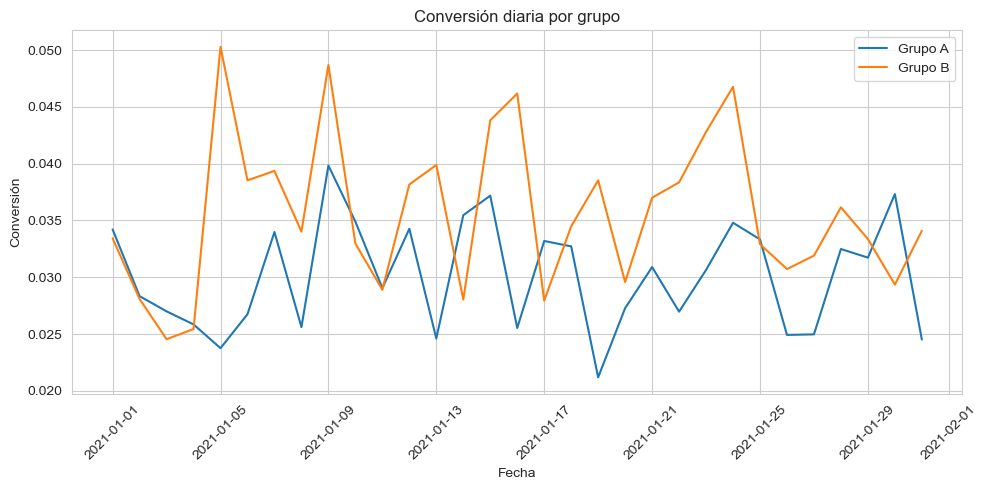

In [29]:
plt.figure(figsize=(10,5))
for grp in ['A','B']:
    grp_data = daily[daily['group']==grp]
    plt.plot(grp_data['date'], grp_data['conversion'], label=f'Grupo {grp}')
plt.title('Conversión diaria por grupo')
plt.xlabel('Fecha')
plt.ylabel('Conversión')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Comparamos curvas para detectar diferencias notorias en la tasa de conversión.

### 3.5 Número de pedidos por usuario

**Qué haremos:** Visualizar la distribución de pedidos por usuario.

**Por qué:** Usuarios con muchos pedidos pueden sesgar la conversión.

**Cómo:** `groupby` sobre `visitorId` y dispersión para detectar heavy buyers.

In [31]:
orders_per_user = orders_df.groupby('visitorId').agg({'transactionId':'nunique'}).reset_index()
orders_per_user.rename(columns={'transactionId':'orders'}, inplace=True)

orders_per_user.head()

,visitorId,orders
0,1000294,1
1,1000408,1
2,1001269,1
3,1002020,1
4,1002733,1


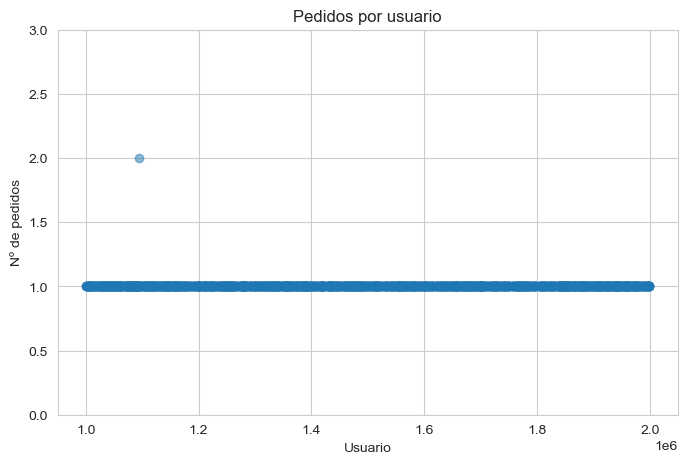

In [32]:


plt.figure(figsize=(8,5))
plt.scatter(orders_per_user['visitorId'], orders_per_user['orders'], alpha=0.5)
plt.title('Pedidos por usuario')
plt.xlabel('Usuario')
plt.ylabel('Nº de pedidos')
plt.ylim(0, orders_per_user['orders'].max()+1)
plt.show()

In [33]:
q95_orders = np.percentile(orders_per_user['orders'], 95)
q99_orders = np.percentile(orders_per_user['orders'], 99)
print(f'Percentil 95: {q95_orders}, Percentil 99: {q99_orders}')

Percentil 95: 1.0, Percentil 99: 1.0


Generalmente consideramos valores por encima del percentil 99 como anomalías.

### 3.6 Precios de pedidos

**Qué haremos:** Examinar la dispersión de montos por pedido.

**Por qué:** Detecta outliers de ingreso que pueden distorsionar el ticket promedio.

**Cómo:** Percentiles 95/99 guían el filtro de valores extremos.

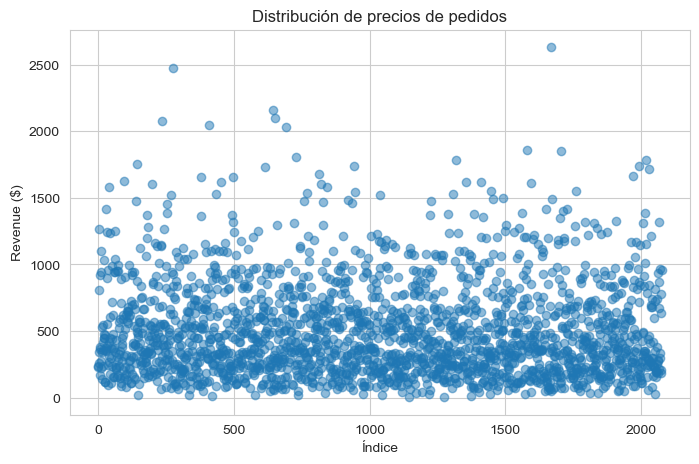

In [34]:
plt.figure(figsize=(8,5))
plt.scatter(range(len(orders_df)), orders_df['revenue'], alpha=0.5)
plt.title('Distribución de precios de pedidos')
plt.xlabel('Índice')
plt.ylabel('Revenue ($)')
plt.show()

In [35]:
q95_rev = np.percentile(orders_df['revenue'], 95)
q99_rev = np.percentile(orders_df['revenue'], 99)
print(f'Percentil 95: {q95_rev:.2f}, Percentil 99: {q99_rev:.2f}')

Percentil 95: 1198.42, Percentil 99: 1634.55


Definimos el umbral de anomalía de precio en el percentil 99.

### 3.7 Significancia estadística (conversión, datos crudos)

**Qué haremos:** Probar la diferencia de conversión con datos sin filtrar.

**Por qué:** Nos da la primera indicación de significancia.

**Cómo:** Usamos `proportions_ztest` para dos proporciones.

In [36]:
conversions = daily.groupby('group').agg({'orders':'sum', 'visits':'sum'})
conversions

,orders,visits
group,,
A,923,30677
B,1153,32374


In [37]:
success = conversions['orders']
success

group
A     923
B    1153
Name: orders, dtype: int64

In [39]:
trials = conversions['visits']
trials

group
A    30677
B    32374
Name: visits, dtype: int64

In [40]:
stat, pval = proportions_ztest(success, trials)
print(f'Estadístico z: {stat:.4f}, p-valor: {pval:.4f}')

Estadístico z: -3.8875, p-valor: 0.0001


Un p-valor < 0.05 indica diferencia significativa en la conversión.

### 3.8 Significancia estadística (ticket promedio, datos crudos)

**Qué haremos:** Comprobar si el ticket promedio difiere.

**Por qué:** Cantidades monetarias raramente son normales; Mann‑Whitney es robusto.

**Cómo:** Prueba no paramétrica `mannwhitneyu`.

In [41]:
a_revenue = orders_df[orders_df['group']=='A']['revenue']
b_revenue = orders_df[orders_df['group']=='B']['revenue']

u_stat, pval_rev = stats.mannwhitneyu(a_revenue, b_revenue, alternative='two-sided')
print(f'U estadístico: {u_stat}, p-valor: {pval_rev:.4f}')

U estadístico: 538833.0, p-valor: 0.6203


### 3.9 Filtrado de valores atípicos

**Qué haremos:** Repetir el análisis tras eliminar outliers.

**Por qué:** Outliers pueden inflar varianza y ocultar significancia.

**Cómo:** Filtramos usuarios >Q99 pedidos o revenue >Q99.

In [43]:
# Umbrales
orders_threshold = q99_orders
revenue_threshold = q99_rev

print("1", orders_threshold)
print("2", revenue_threshold)

1 1.0
2 1634.5475000000001


In [44]:
# Extraer usuarios con pedidos anómalos
abnormal_users = orders_per_user[orders_per_user['orders'] > orders_threshold]['visitorId']
filtered_orders = orders_df[~orders_df['visitorId'].isin(abnormal_users) & (orders_df['revenue'] <= revenue_threshold)]

In [45]:
# Recalcular diarios con datos filtrados
orders_per_day_f = filtered_orders.groupby(['group', 'date']).agg({'transactionId':'nunique'}).reset_index()
orders_per_day_f.rename(columns={'transactionId':'orders'}, inplace=True)
daily_f = pd.merge(visits_df, orders_per_day_f, on=['group','date'], how='left').fillna(0)
daily_f['conversion'] = daily_f['orders'] / daily_f['visits']

In [46]:
conversions_f = daily_f.groupby('group').agg({'orders':'sum', 'visits':'sum'})
stat_f, pval_f = proportions_ztest(conversions_f['orders'], conversions_f['visits'])
print(f'Conversión filtrada - z: {stat_f:.4f}, p-valor: {pval_f:.4f}')

Conversión filtrada - z: -4.0346, p-valor: 0.0001


In [47]:
a_rev_f = filtered_orders[filtered_orders['group']=='A']['revenue']
b_rev_f = filtered_orders[filtered_orders['group']=='B']['revenue']
u_stat_f, pval_rev_f = stats.mannwhitneyu(a_rev_f, b_rev_f, alternative='two-sided')
print(f'Ticket promedio filtrado - U: {u_stat_f}, p-valor: {pval_rev_f:.4f}')

Ticket promedio filtrado - U: 523712.0, p-valor: 0.7779


### 3.10 Conclusiones y decisión final

**Qué haremos:** Graficar el ingreso acumulado de cada grupo día a día.

**Por qué:** El crecimiento divergente puede indicar un efecto positivo de la variante.

**Cómo:** Agrupamos por fecha y aplicamos `cumsum()` para obtener la curva acumulativa.

Basados en los análisis anteriores:
- **Conversión**: evaluamos p-valores crudos y filtrados.
- **Ticket promedio**: idem.

Si ambos indicadores muestran una mejora significativa (p < 0.05) para el grupo B, se podría considerar a B como ganador y detener la prueba. Si no hay diferencia significativa o los resultados son contradictorios, recomendamos continuar o parar concluyendo que no hay diferencias.

_Nota_: Ajusta las conclusiones según los resultados exactos obtenidos tras ejecutar el notebook._